# A-Weighting Filter

Minimal implementation of an **A-weighting** filter (ANSI S1.4-1983 / IEC 61672-1).
A-weighting approximates human loudness perception: it attenuates low and high frequencies and is flat around 1–4 kHz.

Reference: [endolith/waveform-analysis ABC_weighting.py](https://github.com/endolith/waveform-analysis/blob/master/waveform_analysis/weighting_filters/ABC_weighting.py)

In [1]:
import numpy as np
from numpy import pi
from scipy.signal import bilinear_zpk, freqs, sosfilt, zpk2sos, zpk2tf
import matplotlib.pyplot as plt

## 1. Minimal A-weighting: analog poles/zeros → digital filter

A-weighting = C-weighting base (HPF ~20.6 Hz, LPF ~12.2 kHz) plus two real poles at ~107.7 Hz and ~737.9 Hz. We define analog (z, p, k), normalize to 0 dB at 1 kHz, then apply bilinear transform for a given sample rate.

In [2]:
def a_weighting_digital(fs, output="sos"):
    """
    Design digital A-weighting filter for sampling frequency fs (Hz).
    Returns second-order sections ('sos') by default for stable filtering.
    """
    # C-weighting base: 2 zeros at 0, 4 poles (2 at ~20.6 Hz, 2 at ~12.2 kHz)
    z = np.array([0.0, 0.0])
    p = np.array([
        -2 * pi * 20.598997057568145,
        -2 * pi * 20.598997057568145,
        -2 * pi * 12194.21714799801,
        -2 * pi * 12194.21714799801,
    ])
    k = 1.0

    # A-weighting: add 2 poles at ~107.7 Hz and ~737.9 Hz, 2 zeros at 0
    z = np.concatenate([z, [0.0, 0.0]])
    p = np.concatenate([p, [-2 * pi * 107.65264864304628, -2 * pi * 737.8622307362899]])

    # Normalize to 0 dB at 1 kHz (analog)
    b, a = zpk2tf(z, p, k)
    w_1k = 2 * pi * 1000
    _, h_1k = freqs(b, a, [w_1k])
    k = k / np.abs(h_1k[0])

    # Bilinear transform: analog → digital
    z_d, p_d, k_d = bilinear_zpk(z, p, k, fs)

    if output == "sos":
        return zpk2sos(z_d, p_d, k_d)
    elif output in ("ba", "tf"):
        return zpk2tf(z_d, p_d, k_d)
    else:
        raise ValueError(f"output must be 'sos' or 'ba', got {output}")


fs = 48000  # Hz
sos = a_weighting_digital(fs, output="sos")
b, a = a_weighting_digital(fs, output="ba")
print("Filter designed: fs =", fs, "Hz")

Filter designed: fs = 48000 Hz


## 2. Frequency response

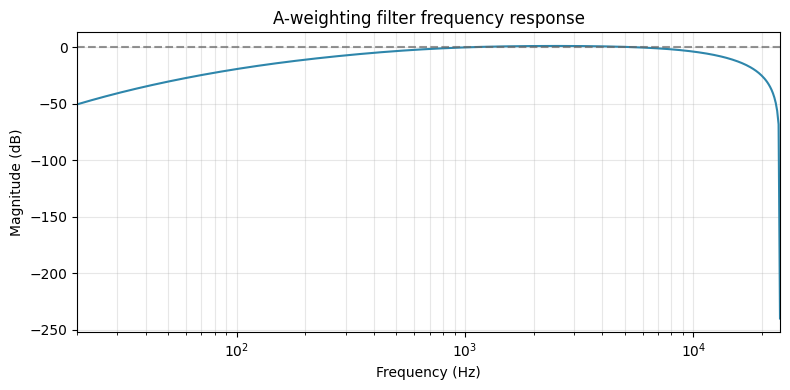

In [3]:
from scipy.signal import freqz

f = np.geomspace(20, fs / 2, 500)
w = 2 * pi * f / fs
w, h = freqz(b, a, w)
h_db = 20 * np.log10(np.maximum(np.abs(h), 1e-12))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(f, h_db, color="#2e86ab")
ax.axhline(0, color="#666", ls="--", alpha=0.7)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("A-weighting filter frequency response")
ax.set_xlim([20, fs / 2])
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Sine sweep: input vs A-weighted output

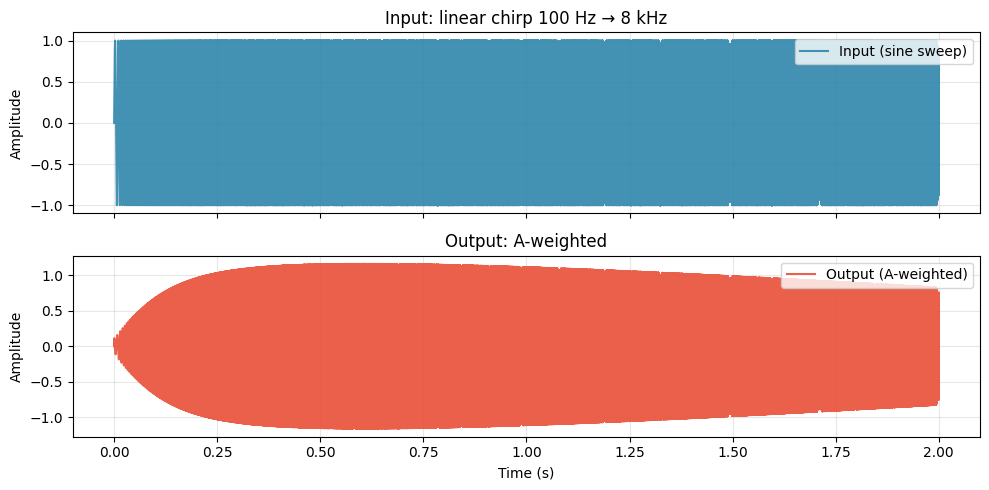

In [4]:
duration = 2.0  # seconds
t = np.arange(0, duration, 1 / fs)
f0, f1 = 100, 8000  # sweep from 100 Hz to 8 kHz
# Linear chirp: phase = 2*pi * (f0*t + (f1-f0)/(2*duration)*t^2)
phase = 2 * pi * (f0 * t + (f1 - f0) / (2 * duration) * t ** 2)
sweep = np.sin(phase).astype(np.float64)

sweep_filtered = sosfilt(sos, sweep)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, sweep, color="#2e86ab", alpha=0.9, label="Input (sine sweep)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Input: linear chirp 100 Hz → 8 kHz")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, sweep_filtered, color="#e94f37", alpha=0.9, label="Output (A-weighted)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Output: A-weighted")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The filtered output is smaller at the start (low frequencies attenuated) and grows as the sweep moves toward 1–4 kHz (where A-weighting is near 0 dB), then gets smaller again at higher frequencies (high-frequency roll-off).